# Experiment 2 Final Defense Report Notebook

**Experiment:** FSLSM-Conditioned Tutor Personalization  
**Purpose:** Evaluate whether FSLSM-personalized tutoring improves learner-facing response quality in a D2L-grounded RAG tutor.

This notebook is designed for the master's final defense report. It focuses on the final Track A automatic metrics and Track B pairwise preference results.

In [1]:
from pathlib import Path
import json
import os

LOCAL_CACHE = Path.cwd().resolve() / ".notebook-cache"
os.environ.setdefault("XDG_CACHE_HOME", str(LOCAL_CACHE))
os.environ.setdefault("MPLCONFIGDIR", str(LOCAL_CACHE / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "experiments" / "exp2_tutor_personalization" / "results" / "exp2_session_metrics.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root with Exp2 results")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
RESULTS_DIR = PROJECT_ROOT / "experiments" / "exp2_tutor_personalization" / "results"
PAIRWISE_DIR = RESULTS_DIR / "pairwise"
FIGURES_DIR = RESULTS_DIR / "final_defense_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir:  {RESULTS_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/nyeinchanaung/Documents/GitHub/mcp-rag
Results dir:  /Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp2_tutor_personalization/results
Figures dir:  /Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp2_tutor_personalization/results/final_defense_figures


## 1. Load Exp2 Results

Exp2 has two evaluation tracks:

- **Track A:** automatic metrics for matched `R0` and `R1` tutor responses
- **Track B:** blind pairwise preference judgement between generic and FSLSM-conditioned responses

In [2]:
session_df = pd.read_csv(RESULTS_DIR / "exp2_session_metrics.csv")
summary = json.loads((RESULTS_DIR / "exp2_results_summary.json").read_text())
pairwise = json.loads((PAIRWISE_DIR / "summary_overall.json").read_text())
pairwise_profile = pd.read_csv(PAIRWISE_DIR / "summary_by_profile.csv")
verdicts = pd.read_csv(PAIRWISE_DIR / "final_verdicts.csv")

metric_order = ["SCS", "Eng", "RR", "CR@5", "CR@10", "ER"]
metric_labels = {
    "SCS": "Style Conformance",
    "Eng": "Engagement",
    "RR": "Response Relevance",
    "CR@5": "CR@5",
    "CR@10": "CR@10",
    "ER": "ER",
}

rows = []
for metric in metric_order:
    sig = summary["significance"][metric]
    rows.append({
        "metric": metric,
        "label": metric_labels[metric],
        "R0_mean": sig["r0_mean"],
        "R1_mean": sig["r1_mean"],
        "delta_R1_minus_R0": sig["mean_diff"],
        "cohens_d": sig["cohens_d"],
        "p_value": sig["p_value"],
        "significant": sig["significant"],
    })
metrics_df = pd.DataFrame(rows)

overview = pd.DataFrame([
    {"Measure": "R0 sessions", "Value": summary["n_sessions_r0"]},
    {"Measure": "R1 sessions", "Value": summary["n_sessions_r1"]},
    {"Measure": "Matched R0/R1 pairs", "Value": summary["n_matched_pairs"]},
    {"Measure": "Profiles", "Value": session_df["profile_label"].nunique()},
    {"Measure": "Questions", "Value": session_df["question_id"].nunique()},
    {"Measure": "R1 pairwise wins", "Value": pairwise["n_r1_win"]},
    {"Measure": "R0 pairwise wins", "Value": pairwise["n_r0_win"]},
    {"Measure": "R1 pairwise win rate", "Value": f"{pairwise['win_rate_r1']:.3f}"},
])
display(overview)
display(metrics_df.style.format({
    "R0_mean": "{:.3f}",
    "R1_mean": "{:.3f}",
    "delta_R1_minus_R0": "{:+.3f}",
    "cohens_d": "{:+.3f}",
    "p_value": "{:.3g}",
}))

,Measure,Value
0,R0 sessions,5760
1,R1 sessions,5760
2,Matched R0/R1 pairs,5760
3,Profiles,16
4,Questions,72
5,R1 pairwise wins,5419
6,R0 pairwise wins,341
7,R1 pairwise win rate,0.941


,metric,label,R0_mean,R1_mean,delta_R1_minus_R0,cohens_d,p_value,significant
0,SCS,Style Conformance,0.261,0.469,+0.208,+2.367,0,True
1,Eng,Engagement,3.247,3.890,+0.643,+1.491,0,True
2,RR,Response Relevance,3.788,3.785,-0.003,-0.003,0.683,False
3,CR@5,CR@5,0.159,0.155,-0.004,-0.022,0.0196,True
4,CR@10,CR@10,0.269,0.254,-0.016,-0.061,1.29e-19,True
5,ER,ER,0.340,0.333,-0.006,-0.013,0.0277,True


## 2. Track A: Automatic Metric Comparison

The main automatic result is that FSLSM conditioning substantially improves style conformance and engagement while preserving response relevance. Retrieval-oriented metrics show a small negative tradeoff.

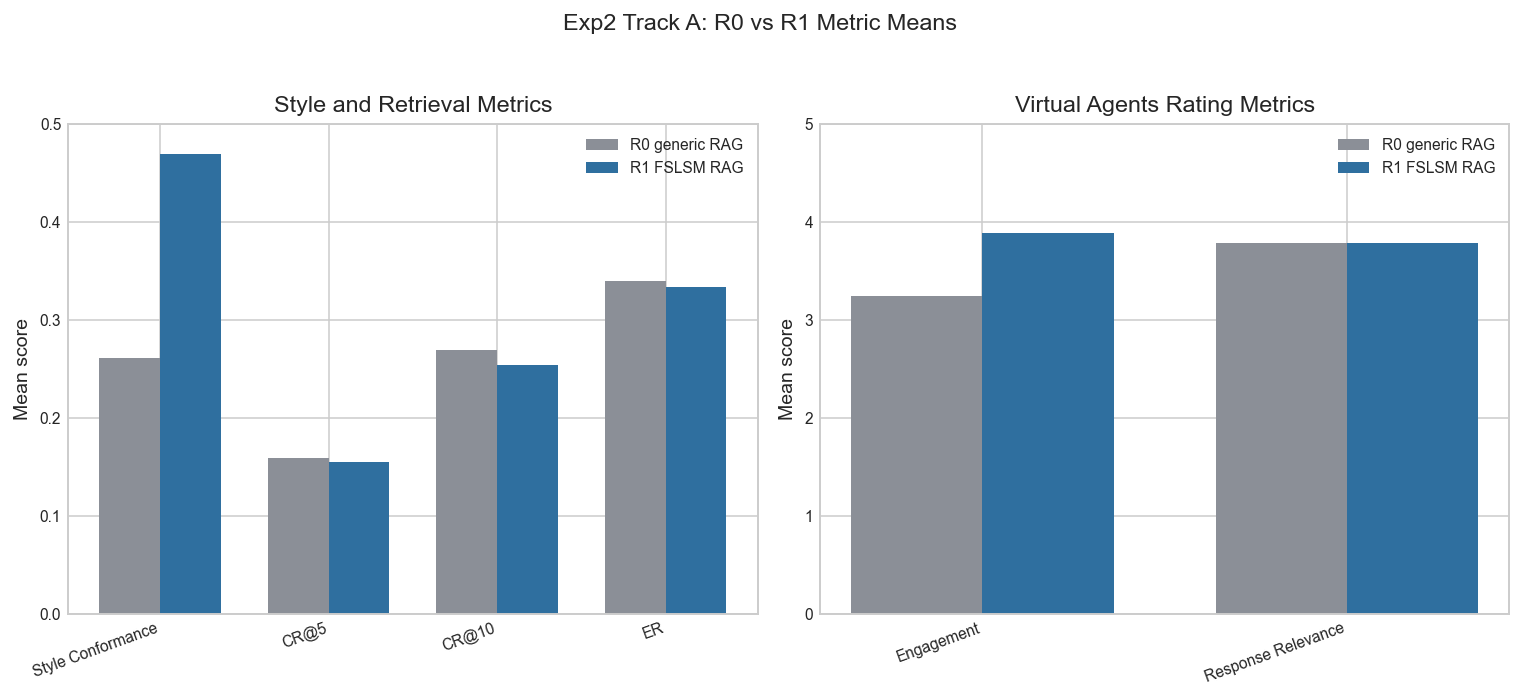

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp2_tutor_personalization/results/final_defense_figures/exp2_defense_track_a_metric_means.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

left_metrics = ["SCS", "CR@5", "CR@10", "ER"]
right_metrics = ["Eng", "RR"]
for ax, selected, title, ylim in [
    (axes[0], left_metrics, "Style and Retrieval Metrics", (0, 0.5)),
    (axes[1], right_metrics, "Virtual Agents Rating Metrics", (0,5)),
]:
    sub = metrics_df.set_index("metric").loc[selected].reset_index()
    x = np.arange(len(sub))
    width = 0.36
    ax.bar(x - width/2, sub["R0_mean"], width, label="R0 generic RAG", color="#8b8f97")
    ax.bar(x + width/2, sub["R1_mean"], width, label="R1 FSLSM RAG", color="#2f6f9f")
    ax.set_xticks(x)
    ax.set_xticklabels([metric_labels[m] for m in selected], rotation=20, ha="right")
    ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_ylabel("Mean score")
    ax.legend()
fig.suptitle("Exp2 Track A: R0 vs R1 Metric Means", y=1.03)
fig.tight_layout()
out = FIGURES_DIR / "exp2_defense_track_a_metric_means.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

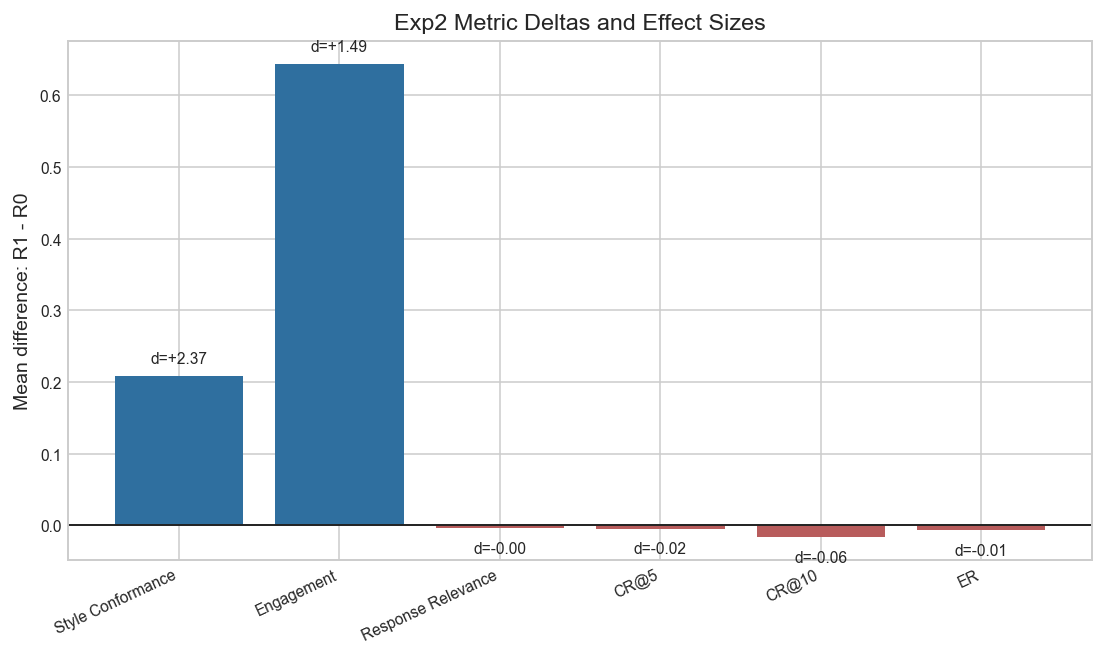

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp2_tutor_personalization/results/final_defense_figures/exp2_defense_metric_deltas.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.8))
plot_df = metrics_df.copy()
colors = ["#2f6f9f" if v > 0 else "#b85c5c" for v in plot_df["delta_R1_minus_R0"]]
ax.bar(plot_df["label"], plot_df["delta_R1_minus_R0"], color=colors)
ax.axhline(0, color="#222222", linewidth=1)
for i, row in plot_df.iterrows():
    ax.text(i, row["delta_R1_minus_R0"] + (0.015 if row["delta_R1_minus_R0"] >= 0 else -0.018),
            f"d={row['cohens_d']:+.2f}", ha="center", va="bottom" if row["delta_R1_minus_R0"] >= 0 else "top", fontsize=8)
ax.set_ylabel("Mean difference: R1 - R0")
ax.set_title("Exp2 Metric Deltas and Effect Sizes")
ax.set_xticks(np.arange(len(plot_df)))
ax.set_xticklabels(plot_df["label"], rotation=25, ha="right")
fig.tight_layout()
out = FIGURES_DIR / "exp2_defense_metric_deltas.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

## 3. Distribution View: Style Conformance And Engagement

Aggregate means can hide variance. These distributions show that the personalized tutor shifts both style conformance and engagement upward across many sessions.

/var/folders/bq/vs89qf7n68vdtt4f5wyyxts40000gn/T/ipykernel_55075/1028128633.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["R0", "R1"], patch_artist=True, widths=0.55, showfliers=False)
/var/folders/bq/vs89qf7n68vdtt4f5wyyxts40000gn/T/ipykernel_55075/1028128633.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["R0", "R1"], patch_artist=True, widths=0.55, showfliers=False)


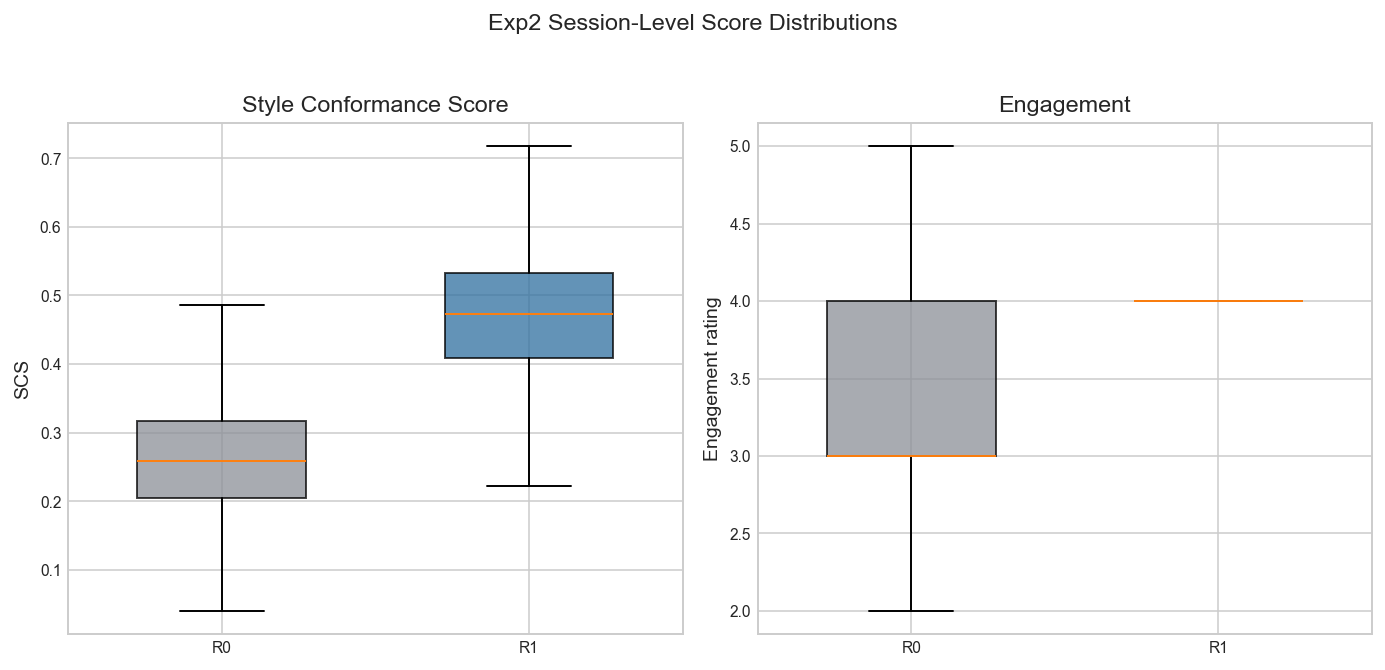

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp2_tutor_personalization/results/final_defense_figures/exp2_defense_score_distributions.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
for ax, metric, title, ylabel in [
    (axes[0], "scs", "Style Conformance Score", "SCS"),
    (axes[1], "engagement", "Engagement", "Engagement rating"),
]:
    data = [session_df.loc[session_df["mode"] == mode, metric].dropna() for mode in ["R0", "R1"]]
    bp = ax.boxplot(data, labels=["R0", "R1"], patch_artist=True, widths=0.55, showfliers=False)
    for patch, color in zip(bp["boxes"], ["#8b8f97", "#2f6f9f"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
fig.suptitle("Exp2 Session-Level Score Distributions", y=1.03)
fig.tight_layout()
out = FIGURES_DIR / "exp2_defense_score_distributions.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

## 4. Retrieval-Style Tradeoff By Profile

This profile-level view shows the core Exp2 tradeoff: personalization moves profiles toward higher style conformance, while CR@5 shifts slightly downward for many profiles.

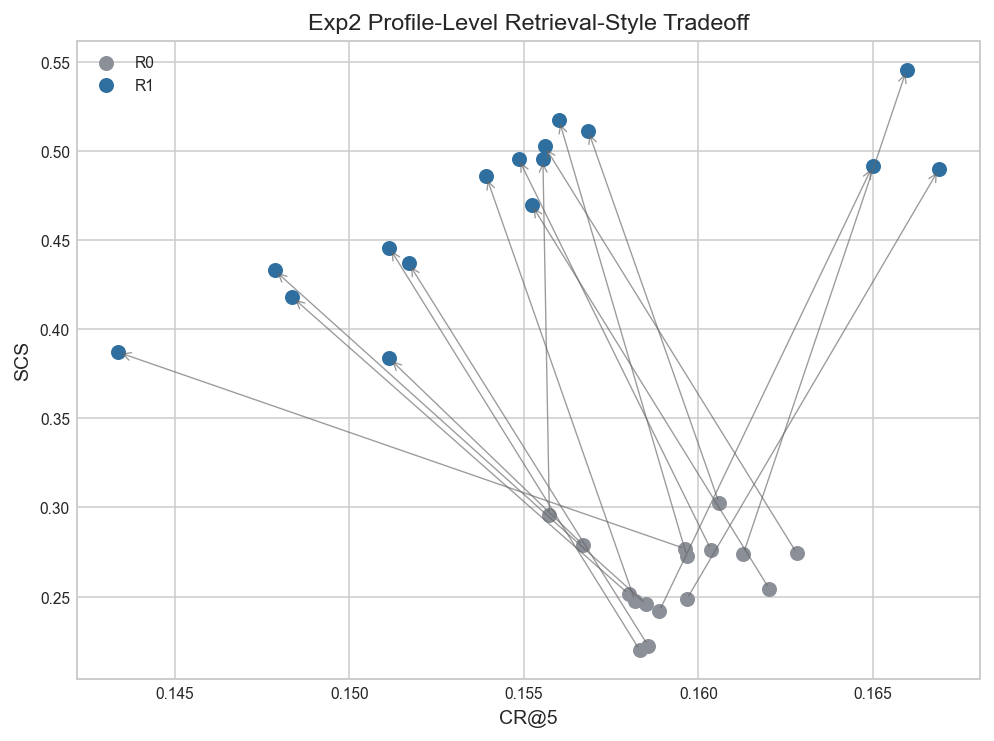

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp2_tutor_personalization/results/final_defense_figures/exp2_defense_profile_tradeoff.png


In [6]:
profile_means = (
    session_df.groupby(["profile_label", "mode"], as_index=False)
    .agg(scs=("scs", "mean"), cr5=("cr5", "mean"), engagement=("engagement", "mean"))
)
r0 = profile_means[profile_means["mode"] == "R0"].set_index("profile_label")
r1 = profile_means[profile_means["mode"] == "R1"].set_index("profile_label")
common = r0.index.intersection(r1.index)

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.scatter(r0.loc[common, "cr5"], r0.loc[common, "scs"], color="#8b8f97", label="R0", s=45)
ax.scatter(r1.loc[common, "cr5"], r1.loc[common, "scs"], color="#2f6f9f", label="R1", s=45)
for profile in common:
    ax.annotate("", xy=(r1.loc[profile, "cr5"], r1.loc[profile, "scs"]), xytext=(r0.loc[profile, "cr5"], r0.loc[profile, "scs"]),
                arrowprops=dict(arrowstyle="->", color="#666666", lw=0.7, alpha=0.65))
ax.set_xlabel("CR@5")
ax.set_ylabel("SCS")
ax.set_title("Exp2 Profile-Level Retrieval-Style Tradeoff")
ax.legend()
fig.tight_layout()
out = FIGURES_DIR / "exp2_defense_profile_tradeoff.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

## 5. Track B: Blind Pairwise Preference

The pairwise judge strongly preferred the personalized response. This provides a second line of evidence beyond individual automatic metric scores.

,Measure,Value
0,Valid pairwise judgements,5760
1,R1 wins,5419
2,R0 wins,341
3,Ties,0
4,R1 win rate,0.941
5,95% CI,"[0.934, 0.947]"
6,Binomial p-value,0


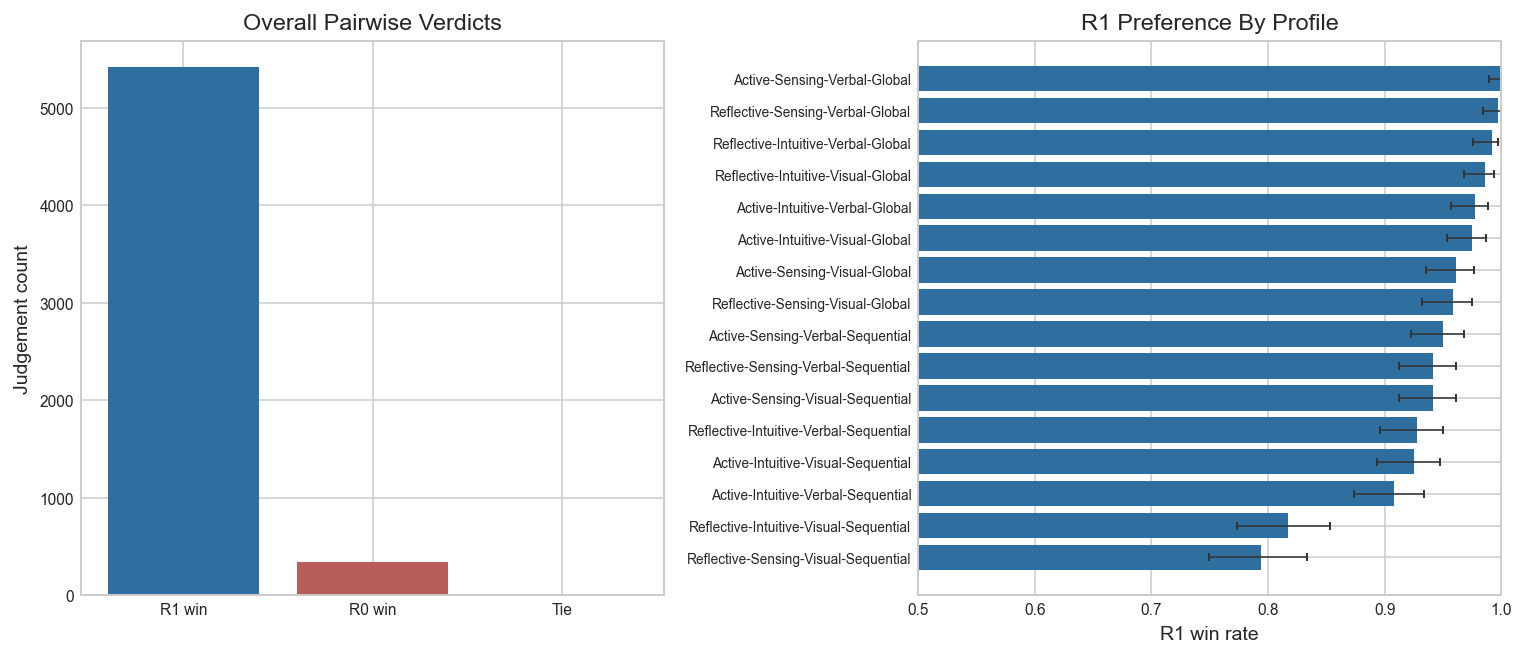

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp2_tutor_personalization/results/final_defense_figures/exp2_defense_pairwise_preference.png


In [7]:
pw_overview = pd.DataFrame([
    {"Measure": "Valid pairwise judgements", "Value": pairwise["n_valid"]},
    {"Measure": "R1 wins", "Value": pairwise["n_r1_win"]},
    {"Measure": "R0 wins", "Value": pairwise["n_r0_win"]},
    {"Measure": "Ties", "Value": pairwise["n_tie"]},
    {"Measure": "R1 win rate", "Value": f"{pairwise['win_rate_r1']:.3f}"},
    {"Measure": "95% CI", "Value": f"[{pairwise['win_rate_r1_ci_lo']:.3f}, {pairwise['win_rate_r1_ci_hi']:.3f}]"},
    {"Measure": "Binomial p-value", "Value": f"{pairwise['binomial_p_value']:.3g}"},
])
display(pw_overview)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].bar(["R1 win", "R0 win", "Tie"], [pairwise["n_r1_win"], pairwise["n_r0_win"], pairwise["n_tie"]], color=["#2f6f9f", "#b85c5c", "#8b8f97"])
axes[0].set_ylabel("Judgement count")
axes[0].set_title("Overall Pairwise Verdicts")

prof = pairwise_profile.sort_values("win_rate_r1")
y = np.arange(len(prof))
axes[1].barh(y, prof["win_rate_r1"], color="#2f6f9f")
axes[1].errorbar(prof["win_rate_r1"], y, xerr=[prof["win_rate_r1"] - prof["ci_lo"], prof["ci_hi"] - prof["win_rate_r1"]], fmt="none", ecolor="#333333", capsize=2, linewidth=0.8)
axes[1].axvline(0.5, color="#222222", linestyle="--", linewidth=1)
axes[1].set_yticks(y)
axes[1].set_yticklabels(prof["profile_label"], fontsize=7)
axes[1].set_xlim(0.5, 1.0)
axes[1].set_xlabel("R1 win rate")
axes[1].set_title("R1 Preference By Profile")
fig.tight_layout()
out = FIGURES_DIR / "exp2_defense_pairwise_preference.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

## 6. FSLSM Pole-Level Personalization Lift

This chart summarizes how much SCS and Engagement improved for each FSLSM pole. It supports the claim that the personalization effect is distributed across learner profiles rather than concentrated in a single profile type.

,dimension,pole,SCS_delta,Eng_delta,n
0,act_ref,Active,+0.178,+0.781,2880
1,act_ref,Reflective,+0.238,+0.506,2880
2,sen_int,Sensing,+0.211,+0.683,2880
3,sen_int,Intuitive,+0.205,+0.604,2880
4,vis_ver,Visual,+0.233,+0.906,2880
5,vis_ver,Verbal,+0.183,+0.381,2880
6,seq_glo,Sequential,+0.217,+0.599,2880
7,seq_glo,Global,+0.199,+0.688,2880


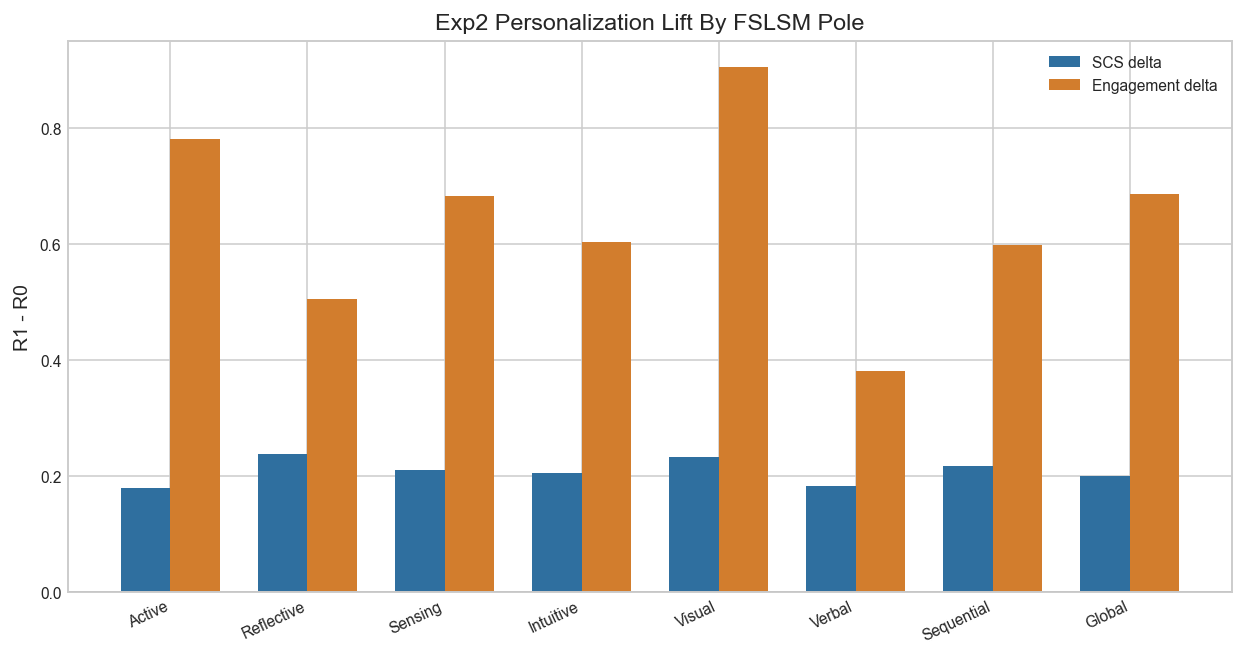

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp2_tutor_personalization/results/final_defense_figures/exp2_defense_dimension_lift.png


In [8]:
dim_rows = []
for dim, poles in summary["by_dimension"].items():
    for pole, vals in poles.items():
        dim_rows.append({
            "dimension": dim,
            "pole": pole,
            "SCS_delta": vals["SCS_R1"] - vals["SCS_R0"],
            "Eng_delta": vals["Eng_R1"] - vals["Eng_R0"],
            "n": vals["n"],
        })
dim_lift = pd.DataFrame(dim_rows)
display(dim_lift.style.format({"SCS_delta": "{:+.3f}", "Eng_delta": "{:+.3f}"}))

fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(dim_lift))
width = 0.36
ax.bar(x - width/2, dim_lift["SCS_delta"], width, label="SCS delta", color="#2f6f9f")
ax.bar(x + width/2, dim_lift["Eng_delta"], width, label="Engagement delta", color="#d27d2d")
ax.axhline(0, color="#222222", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(dim_lift["pole"], rotation=25, ha="right")
ax.set_ylabel("R1 - R0")
ax.set_title("Exp2 Personalization Lift By FSLSM Pole")
ax.legend()
fig.tight_layout()
out = FIGURES_DIR / "exp2_defense_dimension_lift.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

## 7. Defense-Ready Interpretation

Use the following points in the final report or oral defense:

1. **Main effect:** FSLSM-conditioned tutoring strongly improves style conformance and engagement.
2. **Relevance preservation:** Response relevance is essentially unchanged, so personalization does not degrade topical quality.
3. **Retrieval limitation:** CR@5, CR@10, and ER do not improve; they slightly decline. This should be interpreted as a retrieval-style tradeoff, not hidden as a positive result.
4. **Pairwise support:** The blind pairwise judge preferred R1 in 94.1% of matched comparisons, providing strong qualitative preference evidence.
5. **Thesis framing:** Exp2 supports personalization mainly at the generation and presentation layer, while motivating more structured runtime control in Exp3.

In [9]:
figure_files = sorted(FIGURES_DIR.glob("*.png"))
figure_index = pd.DataFrame({
    "figure_file": [p.name for p in figure_files],
    "path": [str(p.relative_to(PROJECT_ROOT)) for p in figure_files],
})
display(Markdown("### Generated figure files"))
display(figure_index)

### Generated figure files

,figure_file,path
0,exp2_defense_dimension_lift.png,experiments/exp2_tutor_personalization/results...
1,exp2_defense_metric_deltas.png,experiments/exp2_tutor_personalization/results...
2,exp2_defense_pairwise_preference.png,experiments/exp2_tutor_personalization/results...
3,exp2_defense_profile_tradeoff.png,experiments/exp2_tutor_personalization/results...
4,exp2_defense_score_distributions.png,experiments/exp2_tutor_personalization/results...
5,exp2_defense_track_a_metric_means.png,experiments/exp2_tutor_personalization/results...
